# Week 02 : 신호의 기초 (Signal Basics)

**신호 및 시스템 (Signals and Systems)**

이번 실습에서는 신호 및 시스템의 기초 개념을 Python을 통해 직접 확인해봅니다.

### 학습 목표
1. **신호의 에너지와 전력 (Signal Energy and Power)** 을 계산하고 시각화할 수 있다.
2. **독립 변수의 변환 (Transformations of the Independent Variable)** — 시간 이동, 시간 반전, 시간 스케일링을 이해한다.
3. **주기 신호 (Periodic Signals)** 의 개념과 기본 주기를 구할 수 있다.
4. **짝수 및 홀수 신호 분해 (Even and Odd Decomposition)** 를 수행할 수 있다.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

---
## 1. 신호의 에너지와 전력 (Signal Energy and Power)

### 연속시간 신호의 에너지

신호 $x(t)$의 **총 에너지(total energy)** 는 다음과 같이 정의됩니다:

$$E_\infty = \int_{-\infty}^{\infty} |x(t)|^2 \, dt$$

유한 구간 $[t_1, t_2]$에서의 에너지:

$$E = \int_{t_1}^{t_2} |x(t)|^2 \, dt$$

### 연속시간 신호의 평균 전력

신호의 **평균 전력(average power)** 은 다음과 같이 정의됩니다:

$$P_\infty = \lim_{T \to \infty} \frac{1}{2T} \int_{-T}^{T} |x(t)|^2 \, dt$$

> **핵심 개념:**
> - $E_\infty < \infty$ 이면 **에너지 신호 (Energy Signal)** — 이 경우 $P_\infty = 0$
> - $0 < P_\infty < \infty$ 이면 **전력 신호 (Power Signal)** — 이 경우 $E_\infty = \infty$
> - 주기 신호는 전력 신호의 대표적 예시

### 예제 1-1: 에너지 신호 — 사각 펄스 (Rectangular Pulse)

$$x(t) = \begin{cases} A, & |t| \leq T_0 \\ 0, & |t| > T_0 \end{cases}$$

이론적 에너지: $E = \int_{-T_0}^{T_0} A^2 \, dt = 2 A^2 T_0$

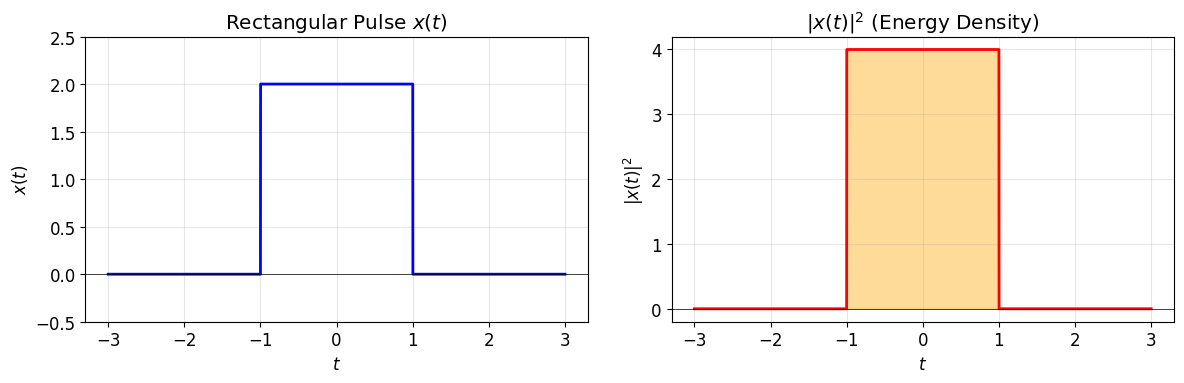

Theoretical Energy:  E = 2 × 2.0² × 1.0 = 8.0000
Numerical Energy:  E ≈ 8.0024


In [2]:
A = 2.0
T0 = 1.0

t = np.linspace(-3, 3, 10000)
dt = t[1] - t[0]

x_rect = np.where(np.abs(t) <= T0, A, 0.0)

energy_numerical = np.sum(np.abs(x_rect)**2) * dt
energy_theoretical = 2 * A**2 * T0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t, x_rect, 'b-')
axes[0].set_title('Rectangular Pulse $x(t)$')
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$x(t)$')
axes[0].set_ylim(-0.5, A + 0.5)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)

axes[1].fill_between(t, np.abs(x_rect)**2, alpha=0.4, color='orange')
axes[1].plot(t, np.abs(x_rect)**2, 'r-')
axes[1].set_title('$|x(t)|^2$ (Energy Density)')
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$|x(t)|^2$')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"Theoretical Energy:  E = 2 × {A}² × {T0} = {energy_theoretical:.4f}")
print(f"Numerical Energy:  E ≈ {energy_numerical:.4f}")

---
## 2. 독립 변수의 변환 (Transformations of the Independent Variable)

신호 $x(t)$에 대해 다음과 같은 변환을 적용할 수 있습니다:

| 변환 | 수식 | 효과 |
|------|------|------|
| **시간 이동 (Time Shift)** | $x(t - t_0)$ | $t_0 > 0$: 오른쪽 이동, $t_0 < 0$: 왼쪽 이동 |
| **시간 반전 (Time Reversal)** | $x(-t)$ | 시간 축 기준 좌우 반전 |
| **시간 스케일링 (Time Scaling)** | $x(at)$ | $\lvert a \rvert > 1$: 압축, $\lvert a \rvert < 1$: 확장 |

### 주의: 복합 변환의 순서

$x(at + b)$ 를 구할 때:
1. **먼저 시간 이동**: $x(t + b)$
2. **그 다음 시간 스케일링**: $x(at + b)$

또는 등가적으로:
1. **먼저 시간 스케일링**: $x(at)$
2. **그 다음 시간 이동**: $x(a(t + b/a)) = x(at + b)$

### 예제 2-1: 시간 이동 (Time Shifting)

원래 신호 $x(t)$와 이동된 신호 $x(t - 2)$, $x(t + 1)$을 비교합니다.

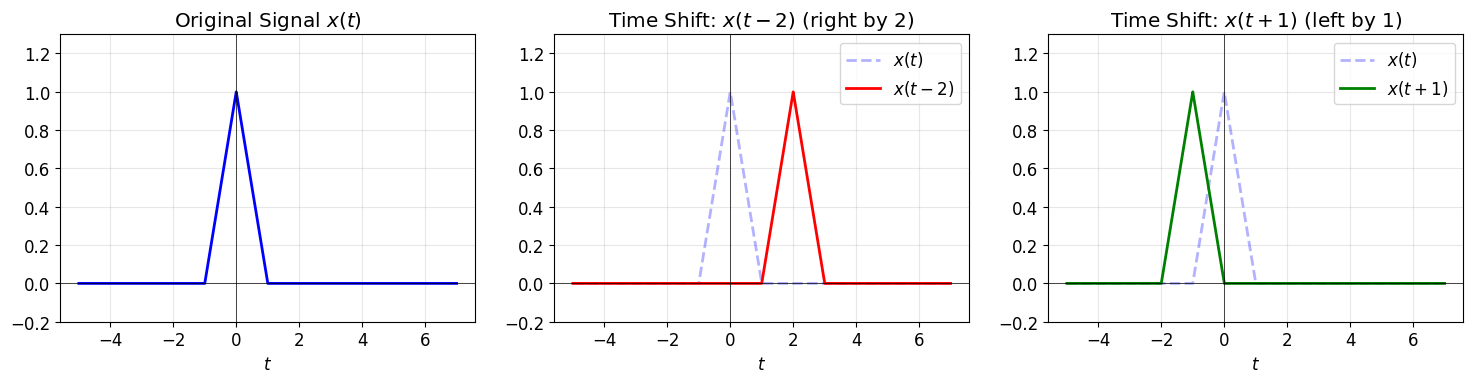

In [3]:
def triangular_pulse(t):
    """Triangular pulse: 1 - |t| for t in [-1, 1], 0 otherwise"""
    return np.where(np.abs(t) <= 1, 1 - np.abs(t), 0.0)

t = np.linspace(-5, 7, 10000)

x_original = triangular_pulse(t)
x_shift_right = triangular_pulse(t - 2)   # x(t - 2): shift right by 2
x_shift_left = triangular_pulse(t + 1)    # x(t + 1): shift left by 1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t, x_original, 'b-')
axes[0].set_title('Original Signal $x(t)$')
axes[0].set_xlabel('$t$')
axes[0].set_ylim(-0.2, 1.3)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].axvline(x=0, color='k', linewidth=0.5)

axes[1].plot(t, x_original, 'b--', alpha=0.3, label='$x(t)$')
axes[1].plot(t, x_shift_right, 'r-', label='$x(t-2)$')
axes[1].set_title('Time Shift: $x(t-2)$ (right by 2)')
axes[1].set_xlabel('$t$')
axes[1].set_ylim(-0.2, 1.3)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].axvline(x=0, color='k', linewidth=0.5)

axes[2].plot(t, x_original, 'b--', alpha=0.3, label='$x(t)$')
axes[2].plot(t, x_shift_left, 'g-', label='$x(t+1)$')
axes[2].set_title('Time Shift: $x(t+1)$ (left by 1)')
axes[2].set_xlabel('$t$')
axes[2].set_ylim(-0.2, 1.3)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linewidth=0.5)
axes[2].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

### 예제 2-2: 시간 반전 (Time Reversal)

$x(-t)$는 $x(t)$를 시간 축 ($t=0$)에 대해 좌우 반전한 신호입니다.

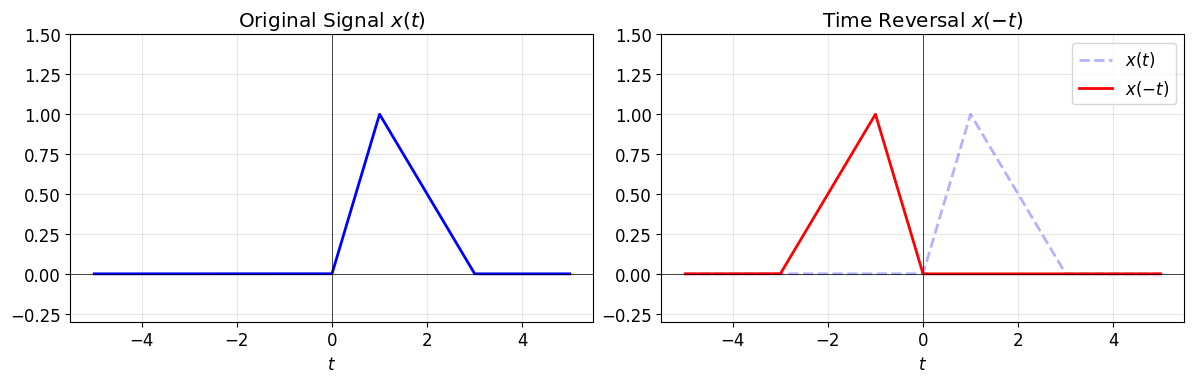

In [4]:
def asymmetric_signal(t):
    """Asymmetric signal: t for 0<=t<=1, (3-t)/2 for 1<t<=3, 0 otherwise"""
    y = np.zeros_like(t)
    mask1 = (t >= 0) & (t <= 1)
    mask2 = (t > 1) & (t <= 3)
    y[mask1] = t[mask1]
    y[mask2] = (3 - t[mask2]) / 2
    return y

t = np.linspace(-5, 5, 10000)

x_original = asymmetric_signal(t)
x_reversed = asymmetric_signal(-t)     # x(-t): time reversal

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t, x_original, 'b-', linewidth=2)
axes[0].set_title('Original Signal $x(t)$')
axes[0].set_xlabel('$t$')
axes[0].set_ylim(-0.3, 1.5)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].axvline(x=0, color='k', linewidth=0.5)

axes[1].plot(t, x_original, 'b--', alpha=0.3, label='$x(t)$')
axes[1].plot(t, x_reversed, 'r-', linewidth=2, label='$x(-t)$')
axes[1].set_title('Time Reversal $x(-t)$')
axes[1].set_xlabel('$t$')
axes[1].set_ylim(-0.3, 1.5)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

### 예제 2-3: 시간 스케일링 (Time Scaling)

- $x(2t)$: 시간 축을 **2배 압축** (신호가 더 빨라짐)
- $x(t/2)$: 시간 축을 **2배 확장** (신호가 더 느려짐)

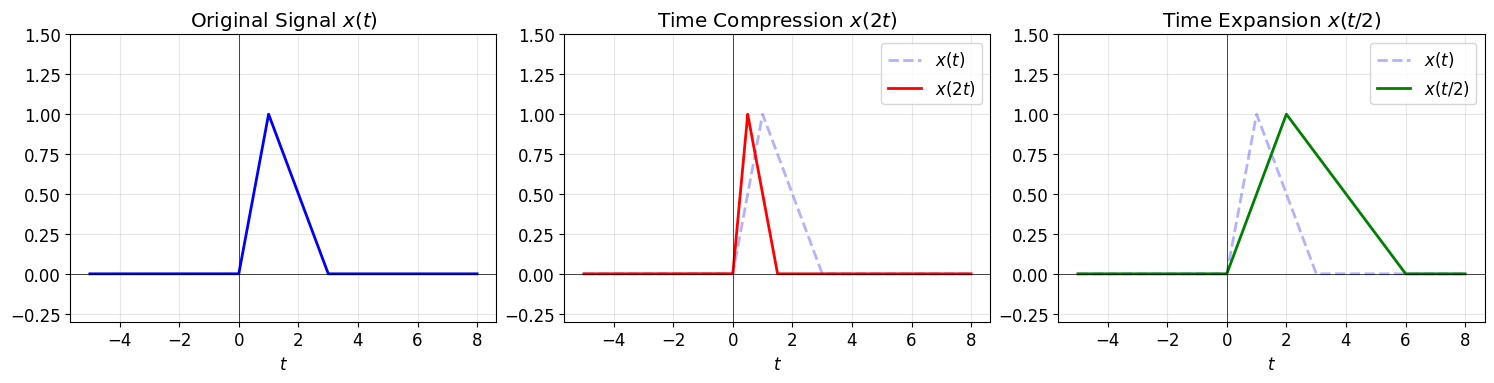

In [5]:
t = np.linspace(-5, 8, 10000)

x_original = asymmetric_signal(t)
x_compressed = asymmetric_signal(2 * t)     # x(2t): compress by 2
x_expanded = asymmetric_signal(t / 2)       # x(t/2): expand by 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t, x_original, 'b-', linewidth=2)
axes[0].set_title('Original Signal $x(t)$')
axes[0].set_xlabel('$t$')
axes[0].set_ylim(-0.3, 1.5)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].axvline(x=0, color='k', linewidth=0.5)

axes[1].plot(t, x_original, 'b--', alpha=0.3, label='$x(t)$')
axes[1].plot(t, x_compressed, 'r-', linewidth=2, label='$x(2t)$')
axes[1].set_title('Time Compression $x(2t)$')
axes[1].set_xlabel('$t$')
axes[1].set_ylim(-0.3, 1.5)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].axvline(x=0, color='k', linewidth=0.5)

axes[2].plot(t, x_original, 'b--', alpha=0.3, label='$x(t)$')
axes[2].plot(t, x_expanded, 'g-', linewidth=2, label='$x(t/2)$')
axes[2].set_title('Time Expansion $x(t/2)$')
axes[2].set_xlabel('$t$')
axes[2].set_ylim(-0.3, 1.5)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linewidth=0.5)
axes[2].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

---
## 3. 주기 신호 (Periodic Signals)

### 정의

연속시간 신호 $x(t)$가 **주기적(periodic)** 이라 함은, 양수 $T > 0$가 존재하여 모든 $t$에 대해 다음이 성립함을 의미합니다:

$$x(t) = x(t + T)$$

이러한 조건을 만족하는 가장 작은 양수 $T$를 **기본 주기(fundamental period)** $T_0$라 합니다.

**기본 주파수(fundamental frequency)**:
$$f_0 = \frac{1}{T_0}, \qquad \omega_0 = \frac{2\pi}{T_0}$$

### 주기 신호의 합

두 주기 신호 $x_1(t)$ (주기 $T_1$)과 $x_2(t)$ (주기 $T_2$)의 합 $x(t) = x_1(t) + x_2(t)$가 주기적이려면:

$$\frac{T_1}{T_2} = \frac{p}{q} \quad \text{(유리수, } p, q \text{는 서로소인 정수)}$$

이때 합 신호의 기본 주기는: $T_0 = p \cdot T_2 = q \cdot T_1 = \text{lcm}(T_1, T_2)$

> **lcm (Least Common Multiple, 최소공배수)** 이란?
>
> 두 수 $a$, $b$의 **최소공배수** $\text{lcm}(a, b)$는 $a$와 $b$ 모두의 배수가 되는 가장 작은 양수입니다.
>
> $$\text{lcm}(a, b) = \frac{|a \cdot b|}{\gcd(a, b)}$$
>
> 예를 들어, $\text{lcm}(4, 6) = 12$, $\text{lcm}(1/3, 1/4) = 1$ 입니다.
>
> 주기 신호에서 $\text{lcm}(T_1, T_2)$는 $T_1$과 $T_2$ 모두의 정수배가 되는 가장 작은 주기를 의미합니다. 즉, 합 신호가 한 번 반복되는 데 필요한 최소 시간입니다.

### 예제 3-1: 주기 신호의 기본 주기 확인

$x(t) = \sin(2\pi t)$ → $T_0 = 1$ 초

주기성을 시각적으로 확인합니다: $x(t)$와 $x(t + T_0)$가 일치하는지 검증합니다.

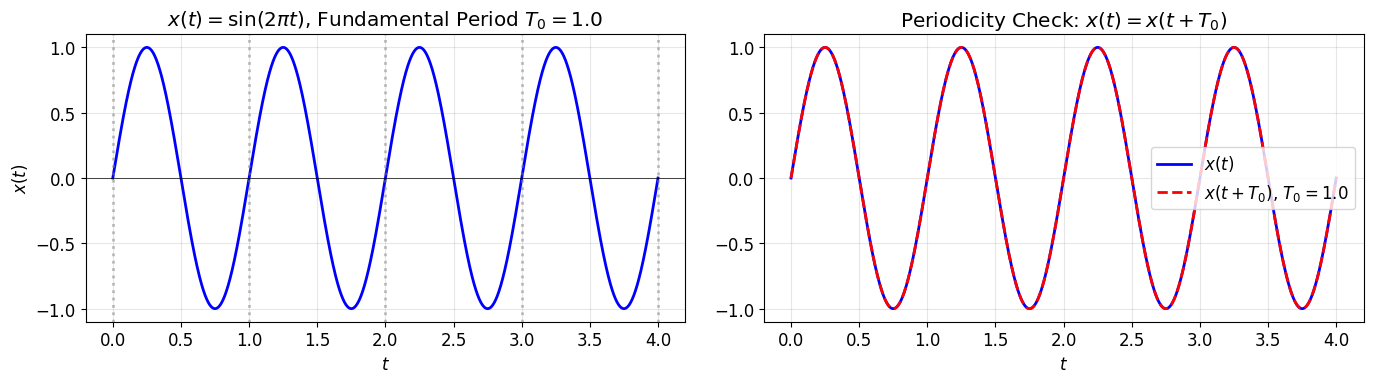

Max Error |x(t) - x(t+T_0)| = 3.80e-15  ->  Periodic!


In [6]:
T0 = 1.0
t = np.linspace(0, 4 * T0, 10000)

x = np.sin(2 * np.pi * t)
x_shifted = np.sin(2 * np.pi * (t + T0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t, x, 'b-', linewidth=2)
axes[0].set_title(f'$x(t) = \\sin(2\\pi t)$, Fundamental Period $T_0 = {T0}$')
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$x(t)$')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)
for k in range(5):
    axes[0].axvline(x=k*T0, color='gray', linestyle=':', alpha=0.5)

axes[1].plot(t, x, 'b-', linewidth=2, label='$x(t)$')
axes[1].plot(t, x_shifted, 'r--', linewidth=2, label=f'$x(t + T_0)$, $T_0={T0}$')
axes[1].set_title('Periodicity Check: $x(t) = x(t + T_0)$')
axes[1].set_xlabel('$t$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

error = np.max(np.abs(x - x_shifted))
print(f"Max Error |x(t) - x(t+T_0)| = {error:.2e}  ->  {'Periodic!' if error < 1e-10 else 'Not Periodic'}")

### 예제 3-2: 주기 신호의 합과 기본 주기

$x_1(t) = \cos(2\pi \cdot 3t)$ → $T_1 = 1/3$

$x_2(t) = \sin(2\pi \cdot 4t)$ → $T_2 = 1/4$

$\frac{T_1}{T_2} = \frac{1/3}{1/4} = \frac{4}{3}$ (유리수) → **주기적**

합 신호의 기본 주기: $T_0 = \text{lcm}(T_1, T_2) = \text{lcm}(1/3, 1/4) = 1$

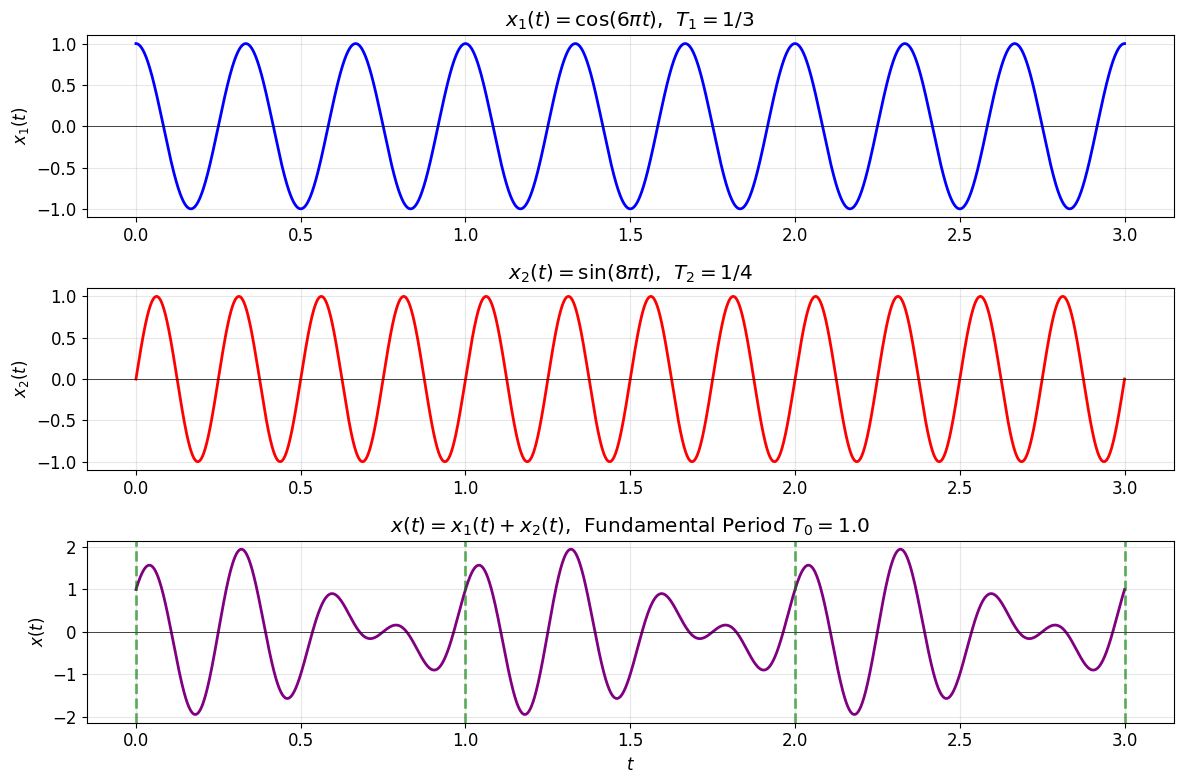

T₁ = 0.3333,  T₂ = 0.2500
T₁/T₂ = 1/3 (rational -> periodic)
Combined Fundamental Period T_0 = 1.0


In [7]:
from fractions import Fraction

def find_combined_period(T1, T2):
    """Compute LCM of two periods using Fraction for exact arithmetic"""
    f1 = Fraction(T1).limit_denominator(1000)
    f2 = Fraction(T2).limit_denominator(1000)
    gcd_val = Fraction(np.gcd(f1.numerator * f2.denominator, f2.numerator * f1.denominator),
                       f1.denominator * f2.denominator)
    lcm_val = (f1 * f2) / gcd_val
    return float(lcm_val)

T1 = 1/3
T2 = 1/4
T0_combined = find_combined_period(T1, T2)

t = np.linspace(0, 3, 10000)

x1 = np.cos(2 * np.pi * 3 * t)
x2 = np.sin(2 * np.pi * 4 * t)
x_sum = x1 + x2

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(t, x1, 'b-')
axes[0].set_title(f'$x_1(t) = \\cos(6\\pi t)$,  $T_1 = 1/3$')
axes[0].set_ylabel('$x_1(t)$')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)

axes[1].plot(t, x2, 'r-')
axes[1].set_title(f'$x_2(t) = \\sin(8\\pi t)$,  $T_2 = 1/4$')
axes[1].set_ylabel('$x_2(t)$')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linewidth=0.5)

axes[2].plot(t, x_sum, 'purple')
axes[2].set_title(f'$x(t) = x_1(t) + x_2(t)$,  Fundamental Period $T_0 = {T0_combined}$')
axes[2].set_xlabel('$t$')
axes[2].set_ylabel('$x(t)$')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linewidth=0.5)
for k in range(4):
    axes[2].axvline(x=k*T0_combined, color='green', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"T₁ = {T1:.4f},  T₂ = {T2:.4f}")
print(f"T₁/T₂ = {Fraction(T1).limit_denominator(100)} (rational -> periodic)")
print(f"Combined Fundamental Period T_0 = {T0_combined}")

### 예제 3-3: 비주기적 합 신호

$x_1(t) = \cos(t)$ → $T_1 = 2\pi$

$x_2(t) = \cos(\sqrt{2}\, t)$ → $T_2 = 2\pi / \sqrt{2} = \sqrt{2}\pi$

$\frac{T_1}{T_2} = \sqrt{2}$ (무리수) → **비주기적!**

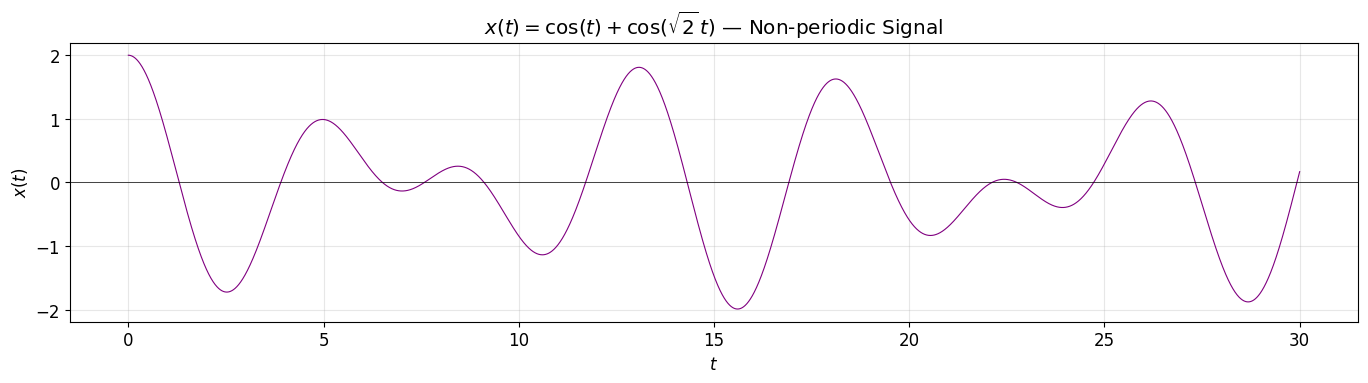

T_1/T_2 = sqrt(2) (irrational) -> The combined signal is NOT periodic.
The plot shows that the exact same pattern never repeats.


In [8]:
t = np.linspace(0, 30, 10000)

x1 = np.cos(t)
x2 = np.cos(np.sqrt(2) * t)
x_sum = x1 + x2

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, x_sum, 'purple', linewidth=0.8)
ax.set_title('$x(t) = \\cos(t) + \\cos(\\sqrt{2}\\, t)$ — Non-periodic Signal')
ax.set_xlabel('$t$')
ax.set_ylabel('$x(t)$')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

print("T_1/T_2 = sqrt(2) (irrational) -> The combined signal is NOT periodic.")
print("The plot shows that the exact same pattern never repeats.")

---
## 4. 짝수 및 홀수 신호 분해 (Even and Odd Decomposition)

### 정의

모든 신호 $x(t)$는 **짝수 부분(even part)** 과 **홀수 부분(odd part)** 의 합으로 유일하게 분해됩니다:

$$x(t) = \underbrace{\text{Ev}\{x(t)\}}_{\text{짝수 부분}} + \underbrace{\text{Od}\{x(t)\}}_{\text{홀수 부분}}$$

여기서:

$$\text{Ev}\{x(t)\} = x_e(t) = \frac{x(t) + x(-t)}{2}$$

$$\text{Od}\{x(t)\} = x_o(t) = \frac{x(t) - x(-t)}{2}$$

### 성질

- **짝수 신호**: $x_e(t) = x_e(-t)$ — 시간 축 대칭
- **홀수 신호**: $x_o(t) = -x_o(-t)$ — 시간 축 반대칭, $x_o(0) = 0$
- **검증**: $x_e(t) + x_o(t) = x(t)$ (항상 성립)

### 예제 4-1: 지수 함수의 짝수/홀수 분해

$x(t) = e^{at}$ 를 짝수/홀수 부분으로 분해하면:

- $x_e(t) = \frac{e^{at} + e^{-at}}{2} = \cosh(at)$
- $x_o(t) = \frac{e^{at} - e^{-at}}{2} = \sinh(at)$

이는 잘 알려진 결과: $e^{at} = \cosh(at) + \sinh(at)$

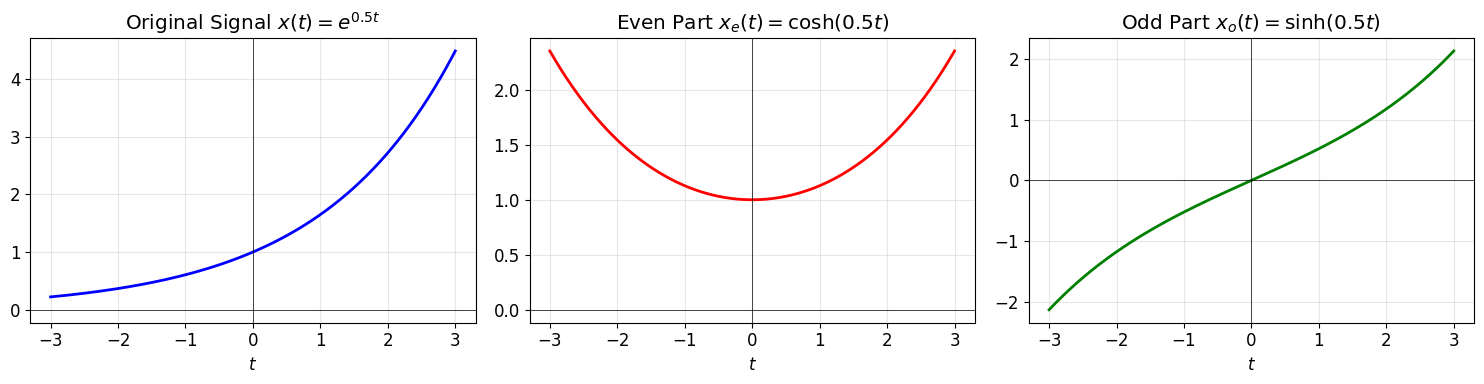

Verification: max|x(t) - (x_e(t) + x_o(t))| = 4.44e-16
-> x_e(t) + x_o(t) = x(t) verified!


In [9]:
a_val = 0.5
t = np.linspace(-3, 3, 10000)

x = np.exp(a_val * t)
x_even = (np.exp(a_val * t) + np.exp(-a_val * t)) / 2   # cosh(at)
x_odd = (np.exp(a_val * t) - np.exp(-a_val * t)) / 2    # sinh(at)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t, x, 'b-', linewidth=2)
axes[0].set_title('Original Signal $x(t) = e^{0.5t}$')
axes[0].set_xlabel('$t$')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].axvline(x=0, color='k', linewidth=0.5)

axes[1].plot(t, x_even, 'r-', linewidth=2)
axes[1].set_title('Even Part $x_e(t) = \\cosh(0.5t)$')
axes[1].set_xlabel('$t$')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].axvline(x=0, color='k', linewidth=0.5)

axes[2].plot(t, x_odd, 'g-', linewidth=2)
axes[2].set_title('Odd Part $x_o(t) = \\sinh(0.5t)$')
axes[2].set_xlabel('$t$')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linewidth=0.5)
axes[2].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

reconstruction_error = np.max(np.abs(x - (x_even + x_odd)))
print(f"Verification: max|x(t) - (x_e(t) + x_o(t))| = {reconstruction_error:.2e}")
print(f"-> x_e(t) + x_o(t) = x(t) verified!") if reconstruction_error < 1e-10 else None

### 예제 4-2: 일반적인 비대칭 신호의 짝수/홀수 분해

앞서 정의한 비대칭 신호 `asymmetric_signal(t)`를 짝수/홀수 부분으로 분해합니다.

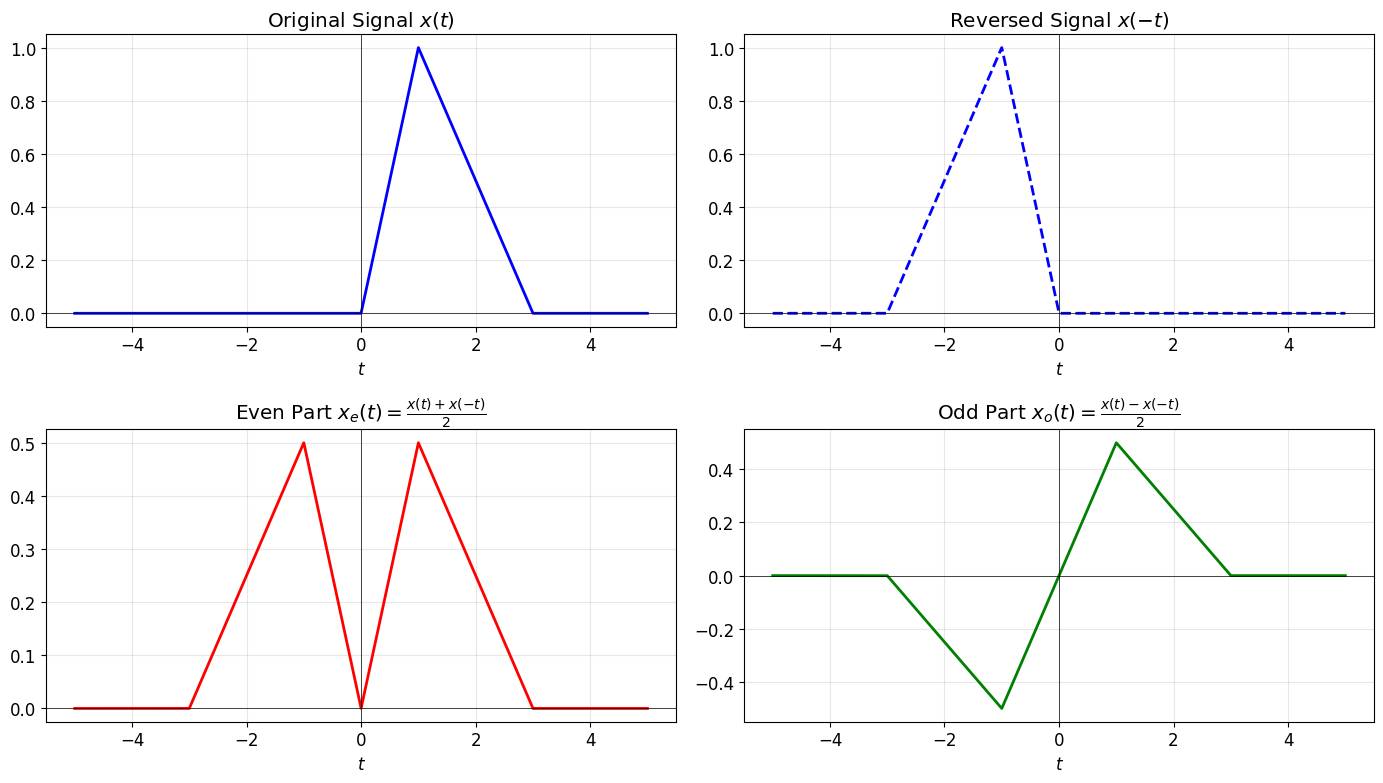

=== Property Verification ===
Even symmetry:  max|x_e(t) - x_e(-t)| = 4.44e-16  ✓
Odd antisymmetry: max|x_o(t) + x_o(-t)| = 4.44e-16  ✓
Reconstruction:  max|x(t) - (x_e + x_o)| = 0.00e+00  ✓


In [10]:
t = np.linspace(-5, 5, 10000)

x = asymmetric_signal(t)
x_neg = asymmetric_signal(-t)

x_even = (x + x_neg) / 2
x_odd = (x - x_neg) / 2

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(t, x, 'b-', linewidth=2)
axes[0, 0].set_title('Original Signal $x(t)$')
axes[0, 0].set_xlabel('$t$')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0, color='k', linewidth=0.5)
axes[0, 0].axvline(x=0, color='k', linewidth=0.5)

axes[0, 1].plot(t, x_neg, 'b--', linewidth=2)
axes[0, 1].set_title('Reversed Signal $x(-t)$')
axes[0, 1].set_xlabel('$t$')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=0, color='k', linewidth=0.5)
axes[0, 1].axvline(x=0, color='k', linewidth=0.5)

axes[1, 0].plot(t, x_even, 'r-', linewidth=2)
axes[1, 0].set_title('Even Part $x_e(t) = \\frac{x(t)+x(-t)}{2}$')
axes[1, 0].set_xlabel('$t$')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='k', linewidth=0.5)
axes[1, 0].axvline(x=0, color='k', linewidth=0.5)

axes[1, 1].plot(t, x_odd, 'g-', linewidth=2)
axes[1, 1].set_title('Odd Part $x_o(t) = \\frac{x(t)-x(-t)}{2}$')
axes[1, 1].set_xlabel('$t$')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=0, color='k', linewidth=0.5)
axes[1, 1].axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

# Property verification
print("=== Property Verification ===")
even_check = np.max(np.abs(x_even - x_even[::-1]))
odd_check = np.max(np.abs(x_odd + x_odd[::-1]))
recon_check = np.max(np.abs(x - (x_even + x_odd)))

print(f"Even symmetry:  max|x_e(t) - x_e(-t)| = {even_check:.2e}  ✓" if even_check < 1e-10 else f"Even symmetry error: {even_check}")
print(f"Odd antisymmetry: max|x_o(t) + x_o(-t)| = {odd_check:.2e}  ✓" if odd_check < 1e-10 else f"Odd antisymmetry error: {odd_check}")
print(f"Reconstruction:  max|x(t) - (x_e + x_o)| = {recon_check:.2e}  ✓" if recon_check < 1e-10 else f"Reconstruction error: {recon_check}")

---
## 요약 (Summary)

| 개념 | 핵심 수식 |
|------|-----------|
| 신호 에너지 | $E = \int_{-\infty}^{\infty} \lvert x(t)\rvert^2 \, dt$ |
| 신호 전력 | $P = \lim_{T\to\infty} \frac{1}{2T}\int_{-T}^{T}\lvert x(t)\rvert^2\, dt$ |
| 시간 이동 | $x(t - t_0)$: $t_0>0$ → 오른쪽 이동 |
| 시간 반전 | $x(-t)$: 좌우 반전 |
| 시간 스케일링 | $x(at)$: $\lvert a\rvert>1$ → 압축, $\lvert a\rvert<1$ → 확장 |
| 주기 신호 | $x(t) = x(t+T)$, 기본 주기 $T_0$ |
| 주기 합 조건 | $T_1/T_2$ 가 유리수 |
| 짝수 부분 | $x_e(t) = \frac{x(t)+x(-t)}{2}$ |
| 홀수 부분 | $x_o(t) = \frac{x(t)-x(-t)}{2}$ |

---
*Week 02 끝*